# [Workshop] 스포츠센터 회원 이탈 예측
- 분류
    - KNN
    - Logistic Regression
- Ont-Hot Encoding

<br/>
<br/>

### 모듈 import

In [ ]:
# Google Colab 환경에서만 실행
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

<br/>
<br/>

### 데이터 로드
- 스포츠센터회원 폴더의 다음 파일들을 읽으세요.
    - `use_log.csv`: 센터 이용 이력
    - `customer.csv`: 회원 목록 (탈퇴 회원 포함)
    - `class.csv`: 회원 구분 데이터 (종일, 주간, 야간)
    - `campaign.csv`: 가입 시 행사 종류 데이터 (입회비 할인)

In [4]:
# use_log.csv
df_logs = 
df_logs

,log_id,customer_id,usedate
0,L00000049012330,AS009373,2018-04-01
1,L00000049012331,AS015315,2018-04-01
2,L00000049012332,AS040841,2018-04-01
3,L00000049012333,AS046594,2018-04-01
4,L00000049012334,AS073285,2018-04-01
...,...,...,...
197423,L00000049209753,TS977703,2019-03-31
197424,L00000049209754,TS979550,2019-03-31
197425,L00000049209755,TS995299,2019-03-31
197426,L00000049209756,TS995853,2019-03-31


In [5]:
# customer.csv
df_user_info = 
df_user_info

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted
0,OA832399,XXXX,C01,F,2015-05-01 00:00:00,NaN,CA1,0
1,PL270116,XXXXX,C01,M,2015-05-01 00:00:00,NaN,CA1,0
2,OA974876,XXXXX,C01,M,2015-05-01 00:00:00,NaN,CA1,0
3,HD024127,XXXXX,C01,F,2015-05-01 00:00:00,NaN,CA1,0
4,HD661448,XXXXX,C03,F,2015-05-01 00:00:00,NaN,CA1,0
...,...,...,...,...,...,...,...,...
4187,HD676663,XXXX,C01,M,2019-03-14 00:00:00,NaN,CA1,0
4188,HD246549,XXXXX,C01,F,2019-03-14 00:00:00,NaN,CA1,0
4189,GD037007,XXXXX,C03,M,2019-03-14 00:00:00,NaN,CA1,0
4190,OA953150,XXXXX,C01,M,2019-03-14 00:00:00,NaN,CA1,0


In [6]:
# df_user_info의 name 열을 삭제하세요.
df_user_info = 
df_user_info

,customer_id,class,gender,start_date,end_date,campaign_id,is_deleted
0,OA832399,C01,F,2015-05-01 00:00:00,NaN,CA1,0
1,PL270116,C01,M,2015-05-01 00:00:00,NaN,CA1,0
2,OA974876,C01,M,2015-05-01 00:00:00,NaN,CA1,0
3,HD024127,C01,F,2015-05-01 00:00:00,NaN,CA1,0
4,HD661448,C03,F,2015-05-01 00:00:00,NaN,CA1,0
...,...,...,...,...,...,...,...
4187,HD676663,C01,M,2019-03-14 00:00:00,NaN,CA1,0
4188,HD246549,C01,F,2019-03-14 00:00:00,NaN,CA1,0
4189,GD037007,C03,M,2019-03-14 00:00:00,NaN,CA1,0
4190,OA953150,C01,M,2019-03-14 00:00:00,NaN,CA1,0


In [7]:
# class.csv
df_class = 
df_class

,class,class_name,price
0,C01,0_종일,10500
1,C02,1_주간,7500
2,C03,2_야간,6000


In [8]:
# campaign.csv
df_campaign = 
df_campaign

,campaign_id,campaign_name
0,CA1,2_일반
1,CA2,0_입회비반액할인
2,CA3,1_입회비무료


<br/>
<br/>

### 데이터 병합
- df_user_info, df_class, df_campaign 세 개의 데이터프레임을 순차적으로 병합

In [9]:
# df_user_info와 df_class를 class 열을 기준으로 병합하여 user에 저장하세요.
user = 
user

,customer_id,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price
0,OA832399,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500
1,PL270116,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500
2,OA974876,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500
3,HD024127,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500
4,HD661448,C03,F,2015-05-01 00:00:00,NaN,CA1,0,2_야간,6000
...,...,...,...,...,...,...,...,...,...
4187,HD676663,C01,M,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500
4188,HD246549,C01,F,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500
4189,GD037007,C03,M,2019-03-14 00:00:00,NaN,CA1,0,2_야간,6000
4190,OA953150,C01,M,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500


In [10]:
# user와 df_campaign을 campaign_id 열을 기준으로 병합하여 user에 저장하세요.
user = 
user

,customer_id,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,campaign_name
0,OA832399,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
1,PL270116,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
2,OA974876,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
3,HD024127,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
4,HD661448,C03,F,2015-05-01 00:00:00,NaN,CA1,0,2_야간,6000,2_일반
...,...,...,...,...,...,...,...,...,...,...
4187,HD676663,C01,M,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
4188,HD246549,C01,F,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
4189,GD037007,C03,M,2019-03-14 00:00:00,NaN,CA1,0,2_야간,6000,2_일반
4190,OA953150,C01,M,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500,2_일반


In [11]:
# user의 정보를 출력하세요.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    4192 non-null   object
 1   class          4192 non-null   object
 2   gender         4192 non-null   object
 3   start_date     4192 non-null   object
 4   end_date       1350 non-null   object
 5   campaign_id    4192 non-null   object
 6   is_deleted     4192 non-null   int64 
 7   class_name     4192 non-null   object
 8   price          4192 non-null   int64 
 9   campaign_name  4192 non-null   object
dtypes: int64(2), object(8)
memory usage: 327.6+ KB


<br/>
<br/>

### class 확인
- target 컬럼인 `is_deleted` 컬럼의 값 해석

In [12]:
# user의 결측치를 조회하세요.


customer_id         0
class               0
gender              0
start_date          0
end_date         2842
campaign_id         0
is_deleted          0
class_name          0
price               0
campaign_name       0
dtype: int64

In [13]:
# end_date 열이 결측치인 행을 선택하여 출력하세요.


,customer_id,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,campaign_name
0,OA832399,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
1,PL270116,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
2,OA974876,C01,M,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
3,HD024127,C01,F,2015-05-01 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
4,HD661448,C03,F,2015-05-01 00:00:00,NaN,CA1,0,2_야간,6000,2_일반
...,...,...,...,...,...,...,...,...,...,...
4187,HD676663,C01,M,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
4188,HD246549,C01,F,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500,2_일반
4189,GD037007,C03,M,2019-03-14 00:00:00,NaN,CA1,0,2_야간,6000,2_일반
4190,OA953150,C01,M,2019-03-14 00:00:00,NaN,CA1,0,0_종일,10500,2_일반


In [14]:
# end_date 열이 결측치인 행의 is_deleted 열의 값 별 개수를 구하세요.


is_deleted
0    2842
Name: count, dtype: int64

In [15]:
# end_date 열이 결측치가 아닌 행의 is_deleted 열의 값 별 개수를 구하세요.


is_deleted
1    1350
Name: count, dtype: int64

- 결과 해석
|end_date 결측치|end_date 존재|
|:--|:--|
|고객 유지|고객 이탈|
|is_deleted : 0|is_deleted : 1|

### 빈도수 확인

In [16]:
# class_name 값 별 개수를 구하세요.


class_name
0_종일    2045
2_야간    1128
1_주간    1019
Name: count, dtype: int64

In [17]:
# campaign_name 값 별 개수를 구하세요.


campaign_name
2_일반         3050
0_입회비반액할인     650
1_입회비무료       492
Name: count, dtype: int64

In [18]:
# gender 값 별 개수를 구하세요.


gender
M    2209
F    1983
Name: count, dtype: int64

In [19]:
# is_deleted 값 별 개수를 구하세요.


is_deleted
0    2842
1    1350
Name: count, dtype: int64

<br/>
<br/>

### 시계열 데이터 처리
- 가입 날짜, 탈퇴 날짜

In [20]:
# start_date 열과 end_date 열의 데이터 타입을 datetime으로 변환하세요.



In [21]:
# 열 별 데이터 타입을 조회하세요.


customer_id              object
class                    object
gender                   object
start_date       datetime64[ns]
end_date         datetime64[ns]
campaign_id              object
is_deleted                int64
class_name               object
price                     int64
campaign_name            object
dtype: object

In [22]:
# start_date 열에서 연도, 월, 일 정보를 start_year, start_month, start_day 열에 추가하세요.



user

,customer_id,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,campaign_name,start_year,start_month,start_day
0,OA832399,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1
1,PL270116,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1
2,OA974876,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1
3,HD024127,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1
4,HD661448,C03,F,2015-05-01,NaT,CA1,0,2_야간,6000,2_일반,2015,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4187,HD676663,C01,M,2019-03-14,NaT,CA1,0,0_종일,10500,2_일반,2019,3,14
4188,HD246549,C01,F,2019-03-14,NaT,CA1,0,0_종일,10500,2_일반,2019,3,14
4189,GD037007,C03,M,2019-03-14,NaT,CA1,0,2_야간,6000,2_일반,2019,3,14
4190,OA953150,C01,M,2019-03-14,NaT,CA1,0,0_종일,10500,2_일반,2019,3,14


In [23]:
# end_date 열에서 연도, 월, 일 정보를 end_year, end_month, end_day 열에 추가하세요.



user

,customer_id,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,campaign_name,start_year,start_month,start_day,end_year,end_month,end_day
0,OA832399,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1,NaN,NaN,NaN
1,PL270116,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1,NaN,NaN,NaN
2,OA974876,C01,M,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1,NaN,NaN,NaN
3,HD024127,C01,F,2015-05-01,NaT,CA1,0,0_종일,10500,2_일반,2015,5,1,NaN,NaN,NaN
4,HD661448,C03,F,2015-05-01,NaT,CA1,0,2_야간,6000,2_일반,2015,5,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4187,HD676663,C01,M,2019-03-14,NaT,CA1,0,0_종일,10500,2_일반,2019,3,14,NaN,NaN,NaN
4188,HD246549,C01,F,2019-03-14,NaT,CA1,0,0_종일,10500,2_일반,2019,3,14,NaN,NaN,NaN
4189,GD037007,C03,M,2019-03-14,NaT,CA1,0,2_야간,6000,2_일반,2019,3,14,NaN,NaN,NaN
4190,OA953150,C01,M,2019-03-14,NaT,CA1,0,0_종일,10500,2_일반,2019,3,14,NaN,NaN,NaN


<br/>
<br/>

### 월 별 신규 회원 수, 탈퇴 회원 수 확인

In [24]:
# start_year, start_month 별 신규 회원의 수를 start_month에 저장하세요.
start_month = 
start_month

customer_id
start_year start_month             
2015       5                     62
           6                     69
           7                     53
           8                     53
           9                     71
           10                    54
           11                    63
           12                    67
2016       1                     56
           2                     48
           3                     55
           4                     57
           5                     56
           6                     76
           7                     69
           8                     77
           9                     75
           10                    71
           11                    65
           12                    76
2017       1                     75
           2                     74
           3                     72
           4                     99
           5                    105
           6                     95
           7                    100
           8                    122
           9                    115
           10                    98
           11                   108
           12                   160
2018       1                    122
           2                    104
           3                     94
           4                    175
           5                    193
           6                    166
           7                    135
           8                    102
           9                     88
           10                    66
           11                    65
           12                   157
2019       1                     90
           2                     74
           3                     65

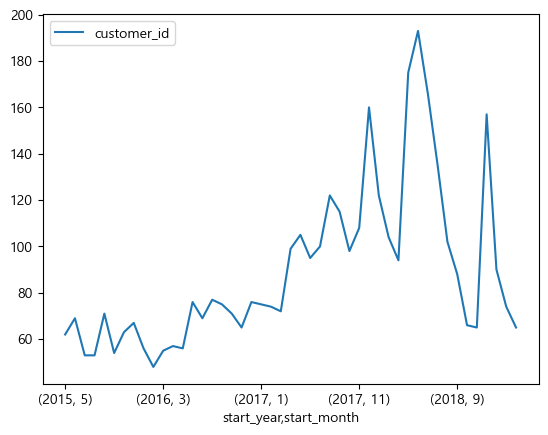

In [25]:
# 해당 결과를 시각화 하세요.
start_month.plot()
plt.show()

In [26]:
# end_year, end_month 별 탈퇴 회원의 수를 end_month에 저장하세요.
end_month = 
end_month

customer_id
end_year end_month             
2018.0   4.0                121
         5.0                125
         6.0                106
         7.0                102
         8.0                113
         9.0                104
         10.0                90
         11.0                89
         12.0               111
2019.0   1.0                129
         2.0                149
         3.0                111

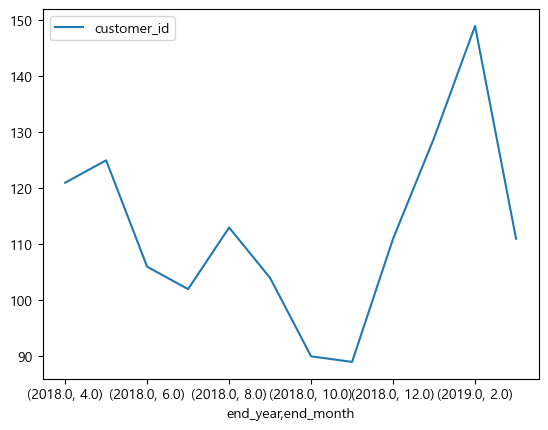

In [27]:
# 해당 결과를 시각화 하세요.
end_month.plot()
plt.show()

<br/>
<br/>

### 머신러닝 적용
- KNeighborsClassifier
- LogisticRegression

In [28]:
# X, y 분리
# X : selection의 컬럼 선택
# y : is_deleted 컬럼
selection = ['class','gender','campaign_id','class_name','price',
             'campaign_name','start_year','start_month','start_day']
X = 
y = 
X

,class,gender,campaign_id,class_name,price,campaign_name,start_year,start_month,start_day
0,C01,F,CA1,0_종일,10500,2_일반,2015,5,1
1,C01,M,CA1,0_종일,10500,2_일반,2015,5,1
2,C01,M,CA1,0_종일,10500,2_일반,2015,5,1
3,C01,F,CA1,0_종일,10500,2_일반,2015,5,1
4,C03,F,CA1,2_야간,6000,2_일반,2015,5,1
...,...,...,...,...,...,...,...,...,...
4187,C01,M,CA1,0_종일,10500,2_일반,2019,3,14
4188,C01,F,CA1,0_종일,10500,2_일반,2019,3,14
4189,C03,M,CA1,2_야간,6000,2_일반,2019,3,14
4190,C01,M,CA1,0_종일,10500,2_일반,2019,3,14


In [29]:
# X를 원핫 인코딩하여 X_onehot에 저장하세요.
X_onehot = 
X_onehot

,price,start_year,start_month,start_day,class_C01,class_C02,class_C03,gender_F,gender_M,campaign_id_CA1,campaign_id_CA2,campaign_id_CA3,class_name_0_종일,class_name_1_주간,class_name_2_야간,campaign_name_0_입회비반액할인,campaign_name_1_입회비무료,campaign_name_2_일반
0,10500,2015,5,1,True,False,False,True,False,True,False,False,True,False,False,False,False,True
1,10500,2015,5,1,True,False,False,False,True,True,False,False,True,False,False,False,False,True
2,10500,2015,5,1,True,False,False,False,True,True,False,False,True,False,False,False,False,True
3,10500,2015,5,1,True,False,False,True,False,True,False,False,True,False,False,False,False,True
4,6000,2015,5,1,False,False,True,True,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4187,10500,2019,3,14,True,False,False,False,True,True,False,False,True,False,False,False,False,True
4188,10500,2019,3,14,True,False,False,True,False,True,False,False,True,False,False,False,False,True
4189,6000,2019,3,14,False,False,True,False,True,True,False,False,False,False,True,False,False,True
4190,10500,2019,3,14,True,False,False,False,True,True,False,False,True,False,False,False,False,True


In [30]:
# 학습, 검증 데이터 분리
# random_state = 0
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = 
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3144, 18), (1048, 18), (3144,), (1048,))

In [31]:
# KNeighborsClassifier 적용
from sklearn.neighbors import KNeighborsClassifier
knn = 



(0.772264631043257, 0.7490458015267175)

In [32]:
# LogisticRegression 적용
from sklearn.linear_model import LogisticRegression
lr = 



(0.7057888040712468, 0.7242366412213741)